# Synthetic Training Example

Train the 1D, 2D and 3D autoencoders on synthetic data for 20 epochs each. The device is picked automatically: CUDA if available, otherwise MPS (Metal), otherwise CPU.

In [1]:
import sys
!pip -q install torchinfo scikit-image

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torchinfo import summary

EPOCHS = 20

def get_device():
    """Pick the best available accelerator: CUDA, then MPS (Metal), then CPU."""
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")

device = get_device()
print(f"Using device: {device}")


Using device: cpu


In [2]:
def compression_factor(depth, in_channels, latent_channels, spatial_dims):
    # each axis shrinks by axis_reduction (e.g. depth=2 -> axis_reduction=4)
    axis_reduction = 2 ** depth
    # spatial_dims axes shrink at the same time, so the element count compounds: axis_reduction**spatial_dims
    spatial_factor = axis_reduction ** spatial_dims
    channel_factor = in_channels / latent_channels
    return axis_reduction, spatial_factor, channel_factor, spatial_factor * channel_factor


def print_compression(name, depth, in_channels, latent_channels, spatial_dims):
    """Print the spatial vs channel breakdown; torchinfo.summary already covers shapes and params."""
    axis, spatial, channel, total = compression_factor(depth, in_channels, latent_channels, spatial_dims)
    print(f"{name} compression factor (depth={depth}): axis /{axis:.0f} -> spatial x{spatial:.2f} (elements) * channels x{channel:.2f} = x{total:.2f}")


def show_architecture(ae, x):
    """Print the full layer-by-layer architecture, input/output shapes and parameter counts."""
    _ = summary(ae, input_data=x, col_names=("input_size", "output_size", "num_params"), verbose=1, depth=2)

In [3]:
def reconstruction_from(output):
    """Return the reconstruction whether a model returns y or (z, y)."""
    return output[-1] if isinstance(output, tuple) else output


def train_autoencoder(model, data, epochs=EPOCHS, lr=1e-3, device=device):
    """Train an autoencoder to reconstruct `data`; returns the per-epoch loss history."""
    model = model.to(device)
    data = data.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    history = []
    model.train()
    for epoch in range(1, epochs + 1):
        optimizer.zero_grad()
        try:
            reconstruction = reconstruction_from(model(data))
        except NotImplementedError:
            # some ops (e.g. MaxPool3d) are not implemented on MPS yet; fall back to CPU
            print(f"Op not supported on {device}, falling back to CPU")
            device = torch.device("cpu")
            model = model.to(device)
            data = data.to(device)
            reconstruction = reconstruction_from(model(data))
        loss = criterion(reconstruction, data)
        loss.backward()
        optimizer.step()
        history.append(loss.item())
        print(f"epoch {epoch:2d}/{epochs} - loss: {loss.item():.6f}")
    return history

In [4]:
def show_examples_1d(data, n_rows=2, n_cols=2):
    """Preview a 2x2 grid of 1D signals: index (n) on x, value on y."""
    data = data.detach().cpu()
    n = torch.arange(data.shape[-1])
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))
    for i, ax in enumerate(axes.flat):
        for c in range(data.shape[1]):
            ax.plot(n, data[i, c], label=f"ch{c}")
        ax.set_xlabel("n")
        ax.set_ylabel("value")
        ax.set_title(f"example {i}")
        ax.legend(fontsize=6)
    plt.tight_layout()
    plt.show()


def show_examples_2d(data, n_rows=2, n_cols=2):
    """Preview a 2x2 grid of 2D image examples."""
    data = data.detach().cpu()
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 3 * n_rows))
    for i, ax in enumerate(axes.flat):
        ax.imshow(data[i, 0], cmap="gray")
        ax.set_title(f"example {i}")
        ax.axis("off")
    plt.tight_layout()
    plt.show()


def show_examples_3d(data, n_examples=2, step_size=2):
    """Preview 3D volumes rendered as closed surfaces (marching cubes)."""
    from skimage.measure import marching_cubes

    data = data.detach().cpu()
    fig = plt.figure(figsize=(4 * n_examples, 4))
    for i in range(n_examples):
        volume = data[i, 0].numpy()
        verts, faces, _, _ = marching_cubes(volume, level=0.5, step_size=step_size)
        ax = fig.add_subplot(1, n_examples, i + 1, projection="3d")
        ax.plot_trisurf(verts[:, 0], verts[:, 1], faces, verts[:, 2], cmap="viridis", linewidth=0)
        ax.set_title(f"example {i}")
        ax.set_axis_off()
    plt.tight_layout()
    plt.show()


def show_reconstruction_1d(truth, output, title=""):
    """Overlay ground truth (red) vs reconstruction (blue) for one example, per channel."""
    truth = truth.detach().cpu()
    output = output.detach().cpu()
    n = torch.arange(truth.shape[-1])
    channels = truth.shape[0]

    fig, axes = plt.subplots(1, channels, figsize=(4 * channels, 3), squeeze=False)
    for c, ax in enumerate(axes[0]):
        ax.plot(n, truth[c], color="red", label="truth")
        ax.plot(n, output[c], color="blue", label="output")
        ax.set_xlabel("n")
        ax.set_ylabel("value")
        ax.set_title(f"channel {c}")
        ax.legend()
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


def show_reconstruction_2d(input_img, output_img, title=""):
    """Show input vs output vs |diff| for one 2D example or 3D slice."""

    input_img = input_img.detach().cpu().squeeze()
    output_img = output_img.detach().cpu().squeeze()
    diff_img = (input_img - output_img).abs()

    fig, axes = plt.subplots(1, 3, figsize=(9, 3))

    # Input
    im0 = axes[0].imshow(input_img, cmap="gray")
    axes[0].set_title("input")
    axes[0].axis("off")
    fig.colorbar(im0, ax=axes[0], fraction=0.046)

    # Reconstruction
    im1 = axes[1].imshow(output_img, cmap="gray")
    axes[1].set_title("output")
    axes[1].axis("off")
    fig.colorbar(im1, ax=axes[1], fraction=0.046)

    # Absolute reconstruction error
    im2 = axes[2].imshow(diff_img, cmap="magma")
    axes[2].set_title("|input - output|")
    axes[2].axis("off")
    fig.colorbar(im2, ax=axes[2], fraction=0.046)

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

## 1D Autoencoder Training

Tensors are shaped as `(batch, channels, length)`. The encoder downsamples with MLP pair-merging blocks, and the decoder upsamples with MLP pair-splitting blocks.

In [5]:
import torch
import torch.nn as nn


class DownBlock1D(nn.Module):
    """[B, C_in, L] -> [B, C_out, L/2]"""

    def __init__(self, in_channels, out_channels, expansion=4):
        super().__init__()

        hidden = expansion * out_channels

        self.mlp = nn.Sequential(
            nn.Linear(2 * in_channels, hidden),
            nn.GELU(),
            nn.Linear(hidden, out_channels),
            nn.LayerNorm(out_channels),
            nn.GELU(),
        )

    def forward(self, x):
        B, C, L = x.shape

        if L % 2:
            raise ValueError(f"Sequence length must be even, got {L}")

        # Pair adjacent positions: [B,C,L] -> [B,L/2,2C]
        x = x.transpose(1, 2).reshape(B, L // 2, 2 * C)

        # [B,L/2,C_out] -> [B,C_out,L/2]
        return self.mlp(x).transpose(1, 2)


class UpBlock1D(nn.Module):
    """[B, C_in, L] -> [B, C_out, 2L]"""

    def __init__(self, in_channels, out_channels, expansion=4, final=False):
        super().__init__()

        self.out_channels = out_channels
        hidden = expansion * in_channels

        self.mlp = nn.Sequential(
            nn.Linear(in_channels, hidden),
            nn.GELU(),
            nn.Linear(hidden, 2 * out_channels),
        )

        self.post = (
            nn.Identity()
            if final
            else nn.Sequential(
                nn.LayerNorm(out_channels),
                nn.GELU(),
            )
        )

    def forward(self, x):
        B, _, L = x.shape

        # [B,C_in,L] -> [B,L,C_in]
        x = x.transpose(1, 2)

        # Predict two output positions from each latent position
        x = self.mlp(x).reshape(B, 2 * L, self.out_channels)
        x = self.post(x)

        # [B,2L,C_out] -> [B,C_out,2L]
        return x.transpose(1, 2)


class Autoencoder1D(nn.Module):
    """Hierarchical MLP autoencoder for 1D sequences."""

    def __init__(
        self,
        in_channels,
        latent_channels,
        initial_channels=8,
        depth=3,
        expansion=4,
        channels=None,
    ):
        super().__init__()

        if depth < 1:
            raise ValueError("depth must be >= 1")

        if channels is None:
            channels = [
                initial_channels * 2**i
                for i in range(depth - 1)
            ]

        self.channels = [in_channels, *channels, latent_channels]
        self.depth = len(self.channels) - 1

        pairs = list(zip(self.channels[:-1], self.channels[1:]))

        self.encoder = nn.ModuleList([
            DownBlock1D(c_in, c_out, expansion)
            for c_in, c_out in pairs
        ])

        decoder_pairs = list(reversed(pairs))

        self.decoder = nn.ModuleList([
            UpBlock1D(
                c_out,
                c_in,
                expansion,
                final=(i == len(decoder_pairs) - 1),
            )
            for i, (c_in, c_out) in enumerate(decoder_pairs)
        ])

    def encode(self, x):
        for block in self.encoder:
            x = block(x)
        return x

    def decode(self, z):
        for block in self.decoder:
            z = block(z)
        return z

    def forward(self, x):
        return self.decode(self.encode(x))

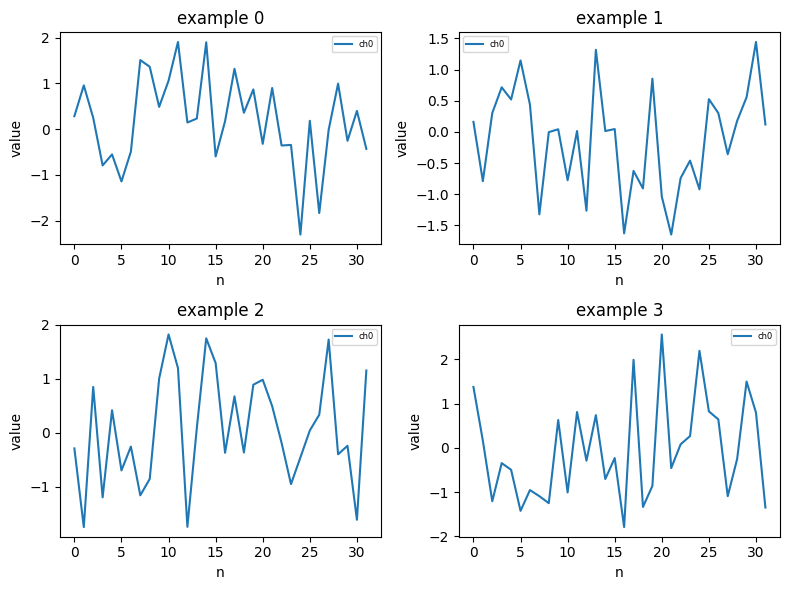

In [9]:
x1 = torch.randn(256, 1, 32)
show_examples_1d(x1)

In [10]:
latent_channels = 16
depth = 4
initial_channels = 8
ae1 = Autoencoder1D(in_channels=1, initial_channels=initial_channels, latent_channels=latent_channels, depth=depth)
summary(ae1, input_data=x1, col_names=("input_size", "output_size", "num_params"), verbose=1, depth=2)
print_compression("Autoencoder1D", depth=depth, in_channels=1, latent_channels=latent_channels, spatial_dims=1)
history1 = train_autoencoder(ae1, x1, epochs=EPOCHS)

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
Autoencoder1D                            [256, 1, 32]              [256, 1, 32]              --
├─ModuleList: 1-1                        --                        --                        --
│    └─DownBlock1D: 2-1                  [256, 1, 32]              [256, 8, 16]              376
│    └─DownBlock1D: 2-2                  [256, 8, 16]              [256, 16, 8]              2,160
│    └─DownBlock1D: 2-3                  [256, 16, 8]              [256, 32, 4]              8,416
│    └─DownBlock1D: 2-4                  [256, 32, 4]              [256, 16, 2]              5,232
├─ModuleList: 1-2                        --                        --                        --
│    └─UpBlock1D: 2-5                    [256, 16, 2]              [256, 32, 4]              5,312
│    └─UpBlock1D: 2-6                    [256, 32, 4]              [256, 16, 8]              8,384
│    └─UpBlock1D: 2

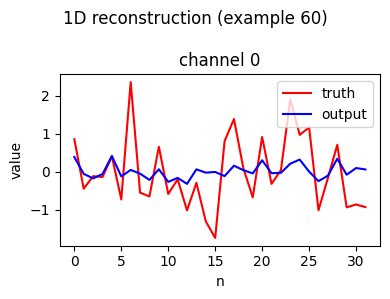

In [11]:
ae1.eval()
model_device = next(ae1.parameters()).device
with torch.no_grad():
    y1 = ae1(x1.to(model_device))

idx = torch.randint(0, x1.shape[0], (1,)).item()
show_reconstruction_1d(x1[idx], y1[idx].cpu(), title=f"1D reconstruction (example {idx})")

## 2D Autoencoder Training

Tensors are shaped as `(batch, channels, height, width)`, built with `Conv2d`, `BatchNorm2d`, `MaxPool2d` and `ConvTranspose2d`. Synthetic data comes from `shapes.py` (`generate_2d_shapes`): circles, squares, triangles and crosses.

In [12]:
%%writefile shapes.py
"""Synthetic geometric shapes generator for 2D image and 3D volume autoencoder demos."""

import torch

VALID_SIZES = (64, 128, 256)
SHAPE_CLASSES_2D = ("circle", "square", "triangle", "cross")
SHAPE_CLASSES_3D = ("sphere", "cube", "cylinder", "cone")


def _grid_2d(size):
    coords = torch.linspace(-1, 1, size)
    yy, xx = torch.meshgrid(coords, coords, indexing="ij")
    return xx, yy


def _grid_3d(size):
    coords = torch.linspace(-1, 1, size)
    zz, yy, xx = torch.meshgrid(coords, coords, coords, indexing="ij")
    return xx, yy, zz


def _draw_2d_shape(shape, size, scale, center):
    xx, yy = _grid_2d(size)
    xx = xx - center[0]
    yy = yy - center[1]
    half = scale
    if shape == "circle":
        mask = xx ** 2 + yy ** 2 <= half ** 2
    elif shape == "square":
        mask = (xx.abs() <= half) & (yy.abs() <= half)
    elif shape == "triangle":
        mask = (yy >= -half) & (yy <= half) & (
            xx.abs() <= half * (1 - (yy + half) / (2 * half))
        )
    elif shape == "cross":
        thickness = half * 0.35
        mask = (
            ((xx.abs() <= thickness) | (yy.abs() <= thickness))
            & (xx.abs() <= half)
            & (yy.abs() <= half)
        )
    else:
        raise ValueError(f"Unknown 2D shape: {shape}")
    return mask.float()


def _draw_3d_shape(shape, size, scale, center):
    xx, yy, zz = _grid_3d(size)
    xx = xx - center[0]
    yy = yy - center[1]
    zz = zz - center[2]
    half = scale
    if shape == "sphere":
        mask = xx ** 2 + yy ** 2 + zz ** 2 <= half ** 2
    elif shape == "cube":
        mask = (xx.abs() <= half) & (yy.abs() <= half) & (zz.abs() <= half)
    elif shape == "cylinder":
        mask = (xx ** 2 + yy ** 2 <= half ** 2) & (zz.abs() <= half)
    elif shape == "cone":
        mask = (
            (zz >= -half)
            & (zz <= half)
            & (
                xx ** 2 + yy ** 2
                <= (half * (1 - (zz + half) / (2 * half))) ** 2
            )
        )
    else:
        raise ValueError(f"Unknown 3D shape: {shape}")
    return mask.float()


def _validate_size(size):
    if size not in VALID_SIZES:
        raise ValueError(
            f"size must be one of {VALID_SIZES}; got {size}. "
            "size controls only the spatial resolution and is independent of depth."
        )


def _validate_n_classes(n_classes, class_names):
    if not isinstance(n_classes, int) or not 1 <= n_classes <= len(class_names):
        raise ValueError(
            f"n_classes must be an integer between 1 and {len(class_names)}; "
            f"got {n_classes}."
        )


def generate_2d_shapes(n_samples, size=64, n_classes=4, seed=None):
    """Generate a synthetic 2D shapes dataset: returns (images, labels).

    `size` only controls the image resolution (height=width=size); it is a separate
    knob from the autoencoder's `depth` and must stay independent of it.
    """
    _validate_size(size)
    _validate_n_classes(n_classes, SHAPE_CLASSES_2D)
    if n_samples < 1:
        raise ValueError(f"n_samples must be >= 1; got {n_samples}.")

    generator = torch.Generator().manual_seed(seed) if seed is not None else None
    shapes = SHAPE_CLASSES_2D[:n_classes]

    images = []
    labels = []
    for i in range(n_samples):
        label = i % len(shapes)
        scale = 0.4 + 0.3 * torch.rand(1, generator=generator).item()
        center = 0.3 * (torch.rand(2, generator=generator) - 0.5) * 2
        mask = _draw_2d_shape(
            shapes[label], size, scale, (center[0].item(), center[1].item())
        )
        images.append(mask.unsqueeze(0))
        labels.append(label)

    images = torch.stack(images)
    labels = torch.tensor(labels, dtype=torch.long)
    return images, labels


def generate_3d_shapes(n_samples, size=64, n_classes=4, seed=None):
    """Generate a synthetic 3D shapes dataset: returns (volumes, labels).

    `size` only controls the volume resolution (depth=height=width=size); it is a
    separate knob from the autoencoder's `depth` and must stay independent of it.
    """
    _validate_size(size)
    _validate_n_classes(n_classes, SHAPE_CLASSES_3D)
    if n_samples < 1:
        raise ValueError(f"n_samples must be >= 1; got {n_samples}.")

    generator = torch.Generator().manual_seed(seed) if seed is not None else None
    shapes = SHAPE_CLASSES_3D[:n_classes]

    volumes = []
    labels = []
    for i in range(n_samples):
        label = i % len(shapes)
        scale = 0.4 + 0.3 * torch.rand(1, generator=generator).item()
        center = 0.2 * (torch.rand(3, generator=generator) - 0.5) * 2
        mask = _draw_3d_shape(
            shapes[label], size, scale, tuple(center.tolist())
        )
        volumes.append(mask.unsqueeze(0))
        labels.append(label)

    volumes = torch.stack(volumes)
    labels = torch.tensor(labels, dtype=torch.long)
    return volumes, labels


Overwriting shapes.py


In [13]:
class ConvBlock2D(nn.Module):
    """Conv -> Activation -> Norm, spatial size unchanged (stride=1)."""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(out_channels),
        )

    def forward(self, x):
        return self.block(x)


class DownBlock2D(nn.Module):
    """Encoder step: ConvBlock followed by pooling, which halves height and width."""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = ConvBlock2D(in_channels, out_channels)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        return self.pool(self.conv(x))


class UpBlock2D(nn.Module):
    """Decoder step: upsampling followed by ConvBlock."""
    def __init__(self, in_channels, out_channels, mode="convtranspose", final=False):
        super().__init__()
        if mode == "convtranspose":
            self.upsample = nn.ConvTranspose2d(
                in_channels, in_channels, kernel_size=2, stride=2
            )
        elif mode == "linear":
            self.upsample = nn.Upsample(
                scale_factor=2, mode="bilinear", align_corners=False
            )
        else:
            raise ValueError(f"Unknown upsampling mode: {mode}")

        self.conv = (
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
            if final
            else ConvBlock2D(in_channels, out_channels)
        )

    def forward(self, x):
        return self.conv(self.upsample(x))


class Autoencoder2D(nn.Module):
    """2D autoencoder with progressive channel growth."""

    def __init__(
        self,
        in_channels,
        initial_channels,
        latent_channels,
        depth=4,
        up_mode="convtranspose"
    ):
        super().__init__()

        if depth < 1:
            raise ValueError("depth must be >= 1")

        channels = (
            [in_channels]
            + [initial_channels * 2**i for i in range(depth - 1)]
            + [latent_channels]
        )
        self.channels = channels

        encoder_pairs = list(zip(channels[:-1], channels[1:]))
        self.encoder = nn.ModuleList([
            DownBlock2D(c_in, c_out)
            for c_in, c_out in encoder_pairs
        ])

        decoder_pairs = [(c_out, c_in) for c_in, c_out in reversed(encoder_pairs)]
        self.decoder = nn.ModuleList([
            UpBlock2D(
                c_in,
                c_out,
                mode=up_mode,
                final=(i == len(decoder_pairs) - 1),
            )
            for i, (c_in, c_out) in enumerate(decoder_pairs)
        ])

    def encode(self, x):
        for block in self.encoder:
            x = block(x)
        return x

    def decode(self, z):
        for block in self.decoder:
            z = block(z)
        return z

    def forward(self, x):
        return self.decode(self.encode(x))


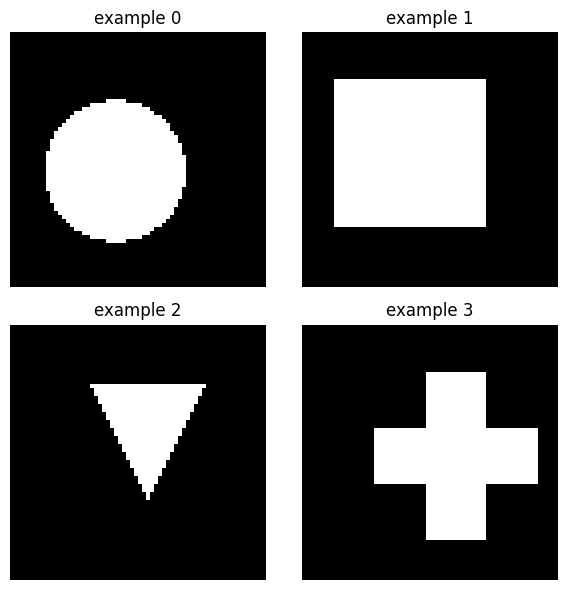

In [14]:
from shapes import generate_2d_shapes

x2, labels2 = generate_2d_shapes(n_samples=64, size=64, n_classes=4, seed=7)
show_examples_2d(x2)

In [15]:
initial_channels=8
latent_channels = 16
depth=5
ae2 = Autoencoder2D(in_channels=1, initial_channels=initial_channels, latent_channels=latent_channels, depth=depth)
summary(ae2, input_data=x2, col_names=("input_size", "output_size", "num_params"), verbose=1, depth=2)
print_compression("Autoencoder2D", depth=depth, in_channels=1, latent_channels=latent_channels, spatial_dims=2)
history2 = train_autoencoder(ae2, x2, epochs=EPOCHS)

Layer (type:depth-idx)                        Input Shape               Output Shape              Param #
Autoencoder2D                                 [64, 1, 64, 64]           [64, 1, 64, 64]           --
├─ModuleList: 1-1                             --                        --                        --
│    └─DownBlock2D: 2-1                       [64, 1, 64, 64]           [64, 8, 32, 32]           96
│    └─DownBlock2D: 2-2                       [64, 8, 32, 32]           [64, 16, 16, 16]          1,200
│    └─DownBlock2D: 2-3                       [64, 16, 16, 16]          [64, 32, 8, 8]            4,704
│    └─DownBlock2D: 2-4                       [64, 32, 8, 8]            [64, 64, 4, 4]            18,624
│    └─DownBlock2D: 2-5                       [64, 64, 4, 4]            [64, 16, 2, 2]            9,264
├─ModuleList: 1-2                             --                        --                        --
│    └─UpBlock2D: 2-6                         [64, 16, 2, 2]            [

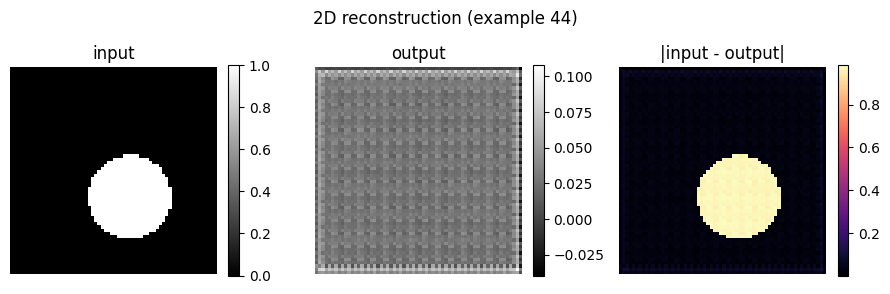

In [16]:
ae2.eval()
model_device = next(ae2.parameters()).device
with torch.no_grad():
    y2 = reconstruction_from(ae2(x2.to(model_device)))

idx = torch.randint(0, x2.shape[0], (1,)).item()
show_reconstruction_2d(x2[idx], y2[idx].cpu(), title=f"2D reconstruction (example {idx})")

## 3D Autoencoder Training

Tensors are shaped as `(batch, channels, depth, height, width)`, built with `Conv3d`, `BatchNorm3d`, `MaxPool3d` and `ConvTranspose3d`. Synthetic data comes from `shapes.py` (`generate_3d_shapes`): spheres, cubes, cylinders and cones.

In [17]:
class ConvBlock3D(nn.Module):
    """Conv -> Activation -> Norm, spatial size unchanged (stride=1)."""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv3d(in_channels, out_channels, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.BatchNorm3d(out_channels),
        )

    def forward(self, x):
        return self.block(x)


class DownBlock3D(nn.Module):
    """Encoder step: ConvBlock followed by pooling, which halves all spatial dimensions."""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = ConvBlock3D(in_channels, out_channels)
        self.pool = nn.MaxPool3d(kernel_size=2, stride=2)

    def forward(self, x):
        return self.pool(self.conv(x))


class UpBlock3D(nn.Module):
    """Decoder step: upsampling followed by ConvBlock."""
    def __init__(self, in_channels, out_channels, mode="convtranspose", final=False):
        super().__init__()
        if mode == "convtranspose":
            self.upsample = nn.ConvTranspose3d(
                in_channels, in_channels, kernel_size=2, stride=2
            )
        elif mode == "linear":
            self.upsample = nn.Upsample(
                scale_factor=2, mode="trilinear", align_corners=False
            )
        else:
            raise ValueError(f"Unknown upsampling mode: {mode}")

        self.conv = (
            nn.Conv3d(in_channels, out_channels, kernel_size=3, padding=1)
            if final
            else ConvBlock3D(in_channels, out_channels)
        )

    def forward(self, x):
        return self.conv(self.upsample(x))


class Autoencoder3D(nn.Module):
    """3D Autoencoder with channels doubling at each depth level."""

    def __init__(
        self,
        in_channels,
        initial_channels=8,
        depth=3,
        latent_channels=None,
        up_mode="convtranspose"
    ):
        super().__init__()

        if depth < 1:
            raise ValueError("depth must be >= 1")

        self.depth = depth

        if latent_channels is None:
            latent_channels = initial_channels * (2 ** (depth - 1))

        channels = [in_channels] + [
            initial_channels * (2 ** i)
            for i in range(depth - 1)
        ] + [latent_channels]

        self.channels = channels

        encoder_pairs = list(zip(channels[:-1], channels[1:]))
        self.encoder = nn.ModuleList([
            DownBlock3D(c_in, c_out)
            for c_in, c_out in encoder_pairs
        ])

        decoder_pairs = [(c_out, c_in) for c_in, c_out in reversed(encoder_pairs)]
        self.decoder = nn.ModuleList([
            UpBlock3D(
                c_in,
                c_out,
                mode=up_mode,
                final=(i == len(decoder_pairs) - 1),
            )
            for i, (c_in, c_out) in enumerate(decoder_pairs)
        ])

    def encode(self, x):
        for block in self.encoder:
            x = block(x)
        return x

    def decode(self, z):
        for block in self.decoder:
            z = block(z)
        return z

    def forward(self, x):
        return self.decode(self.encode(x))


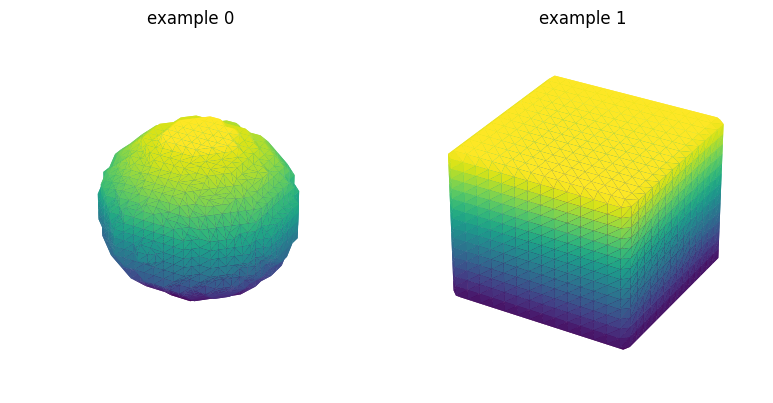

In [18]:
from shapes import generate_3d_shapes

x3, labels3 = generate_3d_shapes(n_samples=8, size=64, n_classes=4, seed=7)
show_examples_3d(x3, n_examples=2)

In [19]:
latent_channels = 32
initial_channels = 4
depth = 4
ae3 = Autoencoder3D(in_channels=1, initial_channels=initial_channels, latent_channels=latent_channels, depth=depth)
summary(ae3, input_data=x3, col_names=("input_size", "output_size", "num_params"), verbose=1, depth=2)
print_compression("Autoencoder3D", depth=depth, in_channels=1, latent_channels=latent_channels, spatial_dims=3)
history3 = train_autoencoder(ae3, x3, epochs=EPOCHS)

Layer (type:depth-idx)                        Input Shape               Output Shape              Param #
Autoencoder3D                                 [8, 1, 64, 64, 64]        [8, 1, 64, 64, 64]        --
├─ModuleList: 1-1                             --                        --                        --
│    └─DownBlock3D: 2-1                       [8, 1, 64, 64, 64]        [8, 4, 32, 32, 32]        120
│    └─DownBlock3D: 2-2                       [8, 4, 32, 32, 32]        [8, 8, 16, 16, 16]        888
│    └─DownBlock3D: 2-3                       [8, 8, 16, 16, 16]        [8, 16, 8, 8, 8]          3,504
│    └─DownBlock3D: 2-4                       [8, 16, 8, 8, 8]          [8, 32, 4, 4, 4]          13,920
├─ModuleList: 1-2                             --                        --                        --
│    └─UpBlock3D: 2-5                         [8, 32, 4, 4, 4]          [8, 16, 8, 8, 8]          22,096
│    └─UpBlock3D: 2-6                         [8, 16, 8, 8, 8]          [

In [20]:
import torch
import matplotlib.pyplot as plt
from skimage.measure import marching_cubes


def show_reconstruction_3d_surface(
    input_vol,
    output_vol,
    title="",
    input_level=None,
    output_level=None,
    diff_level=None,
    step_size=2,
):
    """
    Show input vs output vs |diff| as 3D isosurfaces using marching cubes.

    Expected:
        input_vol, output_vol: tensors shaped [D, H, W] or [1, D, H, W]

    Parameters
    ----------
    input_level, output_level, diff_level:
        Iso-surface threshold for marching cubes.
        If None, uses the midpoint between min and max.
    step_size:
        Larger values make the mesh faster/coarser.
    """

    input_vol = input_vol.detach().cpu().squeeze()
    output_vol = output_vol.detach().cpu().squeeze()

    if input_vol.ndim != 3 or output_vol.ndim != 3:
        raise ValueError(
            f"Expected [D,H,W], got {tuple(input_vol.shape)} and {tuple(output_vol.shape)}"
        )

    diff_vol = (input_vol - output_vol).abs()

    input_np = input_vol.numpy()
    output_np = output_vol.numpy()
    diff_np = diff_vol.numpy()

    def default_level(vol):
        vmin, vmax = vol.min(), vol.max()
        return 0.5 * (vmin + vmax)

    input_level = default_level(input_np) if input_level is None else input_level
    output_level = default_level(output_np) if output_level is None else output_level
    diff_level = default_level(diff_np) if diff_level is None else diff_level

    fig = plt.figure(figsize=(15, 5))

    volumes = [
        (input_np, input_level, "Input", "gray"),
        (output_np, output_level, "Output", "gray"),
        (diff_np, diff_level, "|Input - Output|", "magma"),
    ]

    for i, (vol, level, name, cmap) in enumerate(volumes, 1):
        ax = fig.add_subplot(1, 3, i, projection="3d")

        try:
            verts, faces, _, _ = marching_cubes(
                vol,
                level=level,
                step_size=step_size
            )

            ax.plot_trisurf(
                verts[:, 0],
                verts[:, 1],
                faces,
                verts[:, 2],
                cmap=cmap,
                linewidth=0,
                antialiased=True
            )

            ax.set_title(f"{name}\nlevel={level:.3f}")
            ax.set_axis_off()

        except ValueError as e:
            ax.set_title(f"{name}\n(no surface)")
            ax.text2D(0.05, 0.5, str(e), transform=ax.transAxes)
            ax.set_axis_off()

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

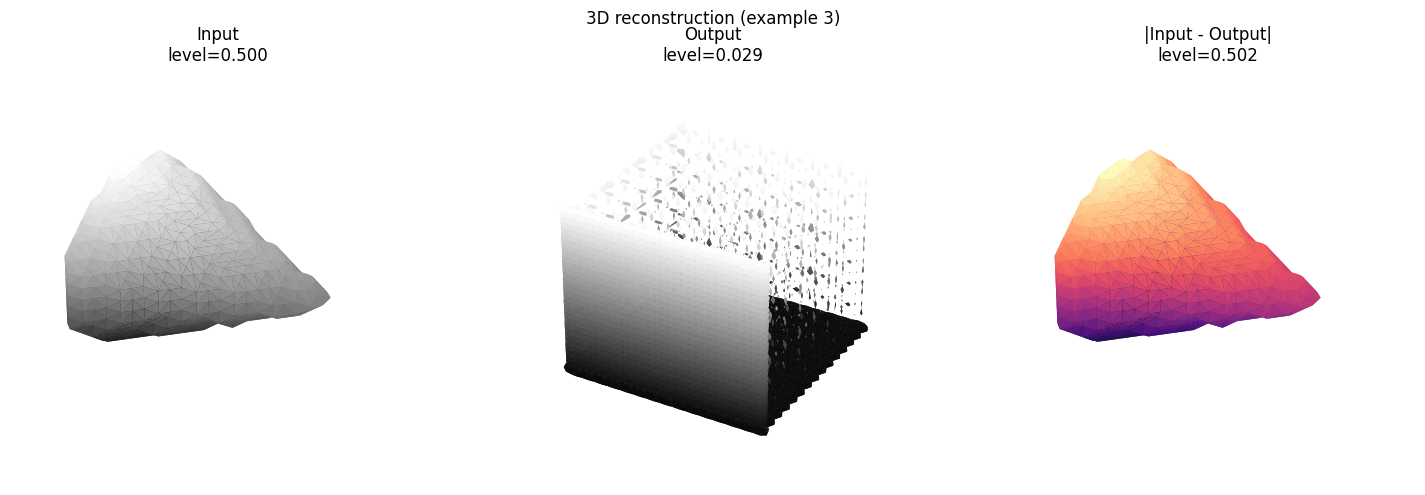

In [21]:
ae3.eval()
model_device = next(ae3.parameters()).device

with torch.no_grad():
    y3 = reconstruction_from(ae3(x3.to(model_device)))

idx = torch.randint(0, x3.shape[0], (1,)).item()

show_reconstruction_3d_surface(
    x3[idx, 0],            # [D, H, W]
    y3[idx, 0].cpu(),      # [D, H, W]
    title=f"3D reconstruction (example {idx})",
    step_size=2
)

## Resultados

Cada autoencoder se entrena durante 20 épocas. Las gráficas finales permiten comparar la entrada con su reconstrucción y visualizar el error absoluto.